In [93]:
import pandas as pd
import numpy as np

In [94]:
df = pd.read_csv(r"C:\Users\Chota Don\Documents\IMDB Movie Reviews\Data\IMDB Dataset.csv")

In [95]:
print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

Dataset Shape
(50000, 2)


In [96]:
print("\n" + "=" * 60)
print("Column Names")
print("=" * 60)
print(df.columns.tolist())


Column Names
['review', 'sentiment']


In [97]:
print("\n" + "=" * 60)
print("Dataset Information")
print("=" * 60)
print(df.info())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB
None


In [98]:
print("\n" + "=" * 60)
print("First 5 Rows")
print("=" * 60)
print(df.head())


First 5 Rows
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [99]:
print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())


Missing Values
review       0
sentiment    0
dtype: int64


In [100]:
print("\n" + "=" * 60)
print("Duplicate Rows")
print("=" * 60)
print(df.duplicated().sum())


Duplicate Rows
418


In [101]:
print("\n" + "=" * 60)
print("Sentiment Distribution")
print("=" * 60)
print(df["sentiment"].value_counts())

print("\nPercentage Distribution:")
print((df["sentiment"].value_counts(normalize=True)* 100).round(2))


Sentiment Distribution
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Percentage Distribution:
sentiment
positive    50.0
negative    50.0
Name: proportion, dtype: float64


In [102]:
df["review_length"] = df["review"].apply(len)

print("\n" + "=" * 60)
print("Review Length Overview")
print("=" * 60)
print(df["review_length"].describe())


Review Length Overview
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64


In [103]:
print("\n" + "=" * 60)
print("Positive Review")
print("=" * 60)

positive_review = df[df["sentiment"] == "positive"]["review"].iloc[0]
print(positive_review)

print("\n" + "=" * 60)
print("Negative Review")
print("=" * 60)

negative_review = df[df["sentiment"] == "negative"]["review"].iloc[0]
print(negative_review)


Positive Review
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

# Text Preprocessing

In [104]:
import re

In [105]:
print("=" * 60)
print("Before Removing Duplicates")
print("=" * 60)
print(df.shape)

df = df.drop_duplicates()

print("\nAfter Removing Duplicates")
print(df.shape)

Before Removing Duplicates
(50000, 3)

After Removing Duplicates
(49582, 3)


In [106]:
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("\n" + "=" * 60)
print("Sentiment Encoding")
print("=" * 60)
print(df["sentiment"].value_counts())


Sentiment Encoding
sentiment
1    24884
0    24698
Name: count, dtype: int64


In [107]:
def clean_text(text):
    #lowercase
    text = text.lower()
    #Removing HTML tags
    text = re.sub(r"<.*?>", " ", text)
    #Removing URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    #Removing  punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    #Removing extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [108]:
df["cleaned_review"] = df["review"].apply(clean_text)

In [109]:
df["cleaned_length"] = df["cleaned_review"].apply(len)

print("\n" + "=" * 60)
print("Cleaned Review Length Overview")
print("=" * 60)

print(df["cleaned_length"].describe())


Cleaned Review Length Overview
count    49582.000000
mean      1249.300694
std        945.419323
min         30.000000
25%        669.000000
50%        926.000000
75%       1515.000000
max      13315.000000
Name: cleaned_length, dtype: float64


In [110]:
print("\n" + "=" * 60)
print("Original Review")
print("=" * 60)
print(df["review"].iloc[0])

print("\n" + "=" * 60)
print("Cleaned Review")
print("=" * 60)
print(df["cleaned_review"].iloc[0])


Original Review
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [111]:
print("\n" + "=" * 60)
print("First Five Rows")
print("=" * 60)

print(df[["cleaned_review", "sentiment"]].head())


First Five Rows
                                      cleaned_review  sentiment
0  one of the other reviewers has mentioned that ...          1
1  a wonderful little production the filming tech...          1
2  i thought this was a wonderful way to spend ti...          1
3  basically there s a family where a little boy ...          0
4  petter mattei s love in the time of money is a...          1


In [112]:
print("\n" + "=" * 60)
print("Final Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)
print(df.isnull().sum())


Final Dataset Shape
(49582, 5)

Missing Values
review            0
sentiment         0
review_length     0
cleaned_review    0
cleaned_length    0
dtype: int64


# TF-IDF Feature Extraction & Train-Test Split

In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [114]:
X = df["cleaned_review"]
y = df["sentiment"]

In [115]:
vectorizer = TfidfVectorizer(max_features=5000,stop_words="english")
X = vectorizer.fit_transform(X)

print("=" * 60)
print("TF-IDF Feature Matrix Shape")
print("=" * 60)
print(X.shape)

TF-IDF Feature Matrix Shape
(49582, 5000)


In [116]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

print("\n" + "=" * 60)
print("Training Set Shape")
print("=" * 60)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\n" + "=" * 60)
print("Testing Set Shape")
print("=" * 60)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


Training Set Shape
X_train: (39665, 5000)
y_train: (39665,)

Testing Set Shape
X_test : (9917, 5000)
y_test : (9917,)


In [117]:
print("\n" + "=" * 60)
print("Number of Features")
print("=" * 60)
print(len(vectorizer.get_feature_names_out()))

print("\nFirst 20 Features:")
print(vectorizer.get_feature_names_out()[:20])


Number of Features
5000

First 20 Features:
['aaron' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absent'
 'absolute' 'absolutely' 'absurd' 'abuse' 'abused' 'abusive' 'abysmal'
 'academy' 'accent' 'accents' 'accept' 'acceptable']


In [118]:
print("\n" + "=" * 60)
print("TF-IDF Matrix (First Review)")
print("=" * 60)

print(X_train[0])


TF-IDF Matrix (First Review)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 3568)	0.048070813350983684
  (0, 4987)	0.12895955034294596
  (0, 2926)	0.03259896057981582
  (0, 3213)	0.052499015253435935
  (0, 4947)	0.06517897820886859
  (0, 3903)	0.16666559235269493
  (0, 4463)	0.11315645583039335
  (0, 853)	0.10035955606512836
  (0, 619)	0.08810058573118318
  (0, 50)	0.06523987230780902
  (0, 1222)	0.19853336118977205
  (0, 2007)	0.09313279570178769
  (0, 2046)	0.09165425430147313
  (0, 3060)	0.12208906980284165
  (0, 2550)	0.10943737081712505
  (0, 2513)	0.10613465489873102
  (0, 353)	0.1083261645621857
  (0, 3496)	0.1032478998748559
  (0, 4527)	0.09310980468967452
  (0, 3929)	0.09431432425506656
  (0, 479)	0.11552288556679004
  (0, 445)	0.5702557066573716
  (0, 2907)	0.11806877376583214
  (0, 4195)	0.12942468002800941
  (0, 151)	0.14966124467291023
  (0, 2204)	0.12050361845422487
  (0, 860)	0.1230624392210513

# Model Training (Logistic Regression & Multinomial Naive Bayes)

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [120]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [121]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print("=" * 60)
print("Both models trained successfully.")
print("=" * 60)

Both models trained successfully.


In [122]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report)

In [123]:
lr_predictions = lr_model.predict(X_test)

print("=" * 60)
print("Logistic Regression Results")
print("=" * 60)

print("Accuracy :", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall   :", recall_score(y_test, lr_predictions))
print("F1 Score :", f1_score(y_test, lr_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_predictions))
print("\nClassification Report")
print(classification_report(y_test, lr_predictions))

Logistic Regression Results
Accuracy : 0.8853483916507008
Precision: 0.8751465416178195
Recall   : 0.8999397227245328
F1 Score : 0.887369985141159

Confusion Matrix
[[4301  639]
 [ 498 4479]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4940
           1       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [124]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

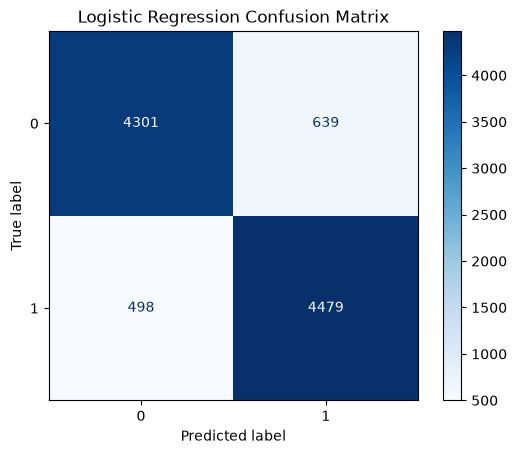

In [125]:
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [126]:
report = pd.DataFrame(classification_report( y_test, lr_predictions, output_dict=True)).transpose()

print(report)

              precision    recall  f1-score      support
0              0.896228  0.870648  0.883253  4940.000000
1              0.875147  0.899940  0.887370  4977.000000
accuracy       0.885348  0.885348  0.885348     0.885348
macro avg      0.885687  0.885294  0.885311  9917.000000
weighted avg   0.885648  0.885348  0.885319  9917.000000


In [127]:
nb_predictions = nb_model.predict(X_test)

print("\n" + "=" * 60)
print("Multinomial Naive Bayes Results")
print("=" * 60)

print("Accuracy :", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions))
print("Recall   :", recall_score(y_test, nb_predictions))
print("F1 Score :", f1_score(y_test, nb_predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, nb_predictions))
print("\nClassification Report")
print(classification_report(y_test, nb_predictions))


Multinomial Naive Bayes Results
Accuracy : 0.8536855904003227
Precision: 0.8492472266244057
Recall   : 0.8613622664255576
F1 Score : 0.8552618453865337

Confusion Matrix
[[4179  761]
 [ 690 4287]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4940
           1       0.85      0.86      0.86      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



# Custom Predictions

In [128]:
custom_reviews = [
    "This movie was absolutely amazing. I loved every minute of it.",
    "This was the worst movie I have ever watched. Completely boring.",
    "The movie was okay. Some parts were good but overall it was average."
]

custom_features = vectorizer.transform(custom_reviews)
predictions = lr_model.predict(custom_features)

print("=" * 60)
print("Custom Predictions")
print("=" * 60)

for review, prediction in zip(custom_reviews, predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"

    print(f"\nReview: {review}")
    print(f"Predicted Sentiment: {sentiment}")

Custom Predictions

Review: This movie was absolutely amazing. I loved every minute of it.
Predicted Sentiment: Positive

Review: This was the worst movie I have ever watched. Completely boring.
Predicted Sentiment: Negative

Review: The movie was okay. Some parts were good but overall it was average.
Predicted Sentiment: Negative


In [129]:
import joblib

joblib.dump(lr_model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("\nModel and Vectorizer saved successfully!")


Model and Vectorizer saved successfully!


# Model Comparison

In [130]:
comparison = pd.DataFrame({

    "Model": ["Logistic Regression", "Multinomial Naive Bayes"],

    "Accuracy": [accuracy_score(y_test, lr_predictions), accuracy_score(y_test, nb_predictions)],

    "Precision": [precision_score(y_test, lr_predictions),precision_score(y_test, nb_predictions)],

    "Recall": [recall_score(y_test, lr_predictions),recall_score(y_test, nb_predictions)],

    "F1 Score": [f1_score(y_test, lr_predictions),f1_score(y_test, nb_predictions)]
})

print(comparison)

                     Model  Accuracy  Precision    Recall  F1 Score
0      Logistic Regression  0.885348   0.875147  0.899940  0.887370
1  Multinomial Naive Bayes  0.853686   0.849247  0.861362  0.855262
